<a href="https://colab.research.google.com/github/sergiocostaifes/PPCOMP_RNA/blob/main/RNA_trabalho01_mlp_backpropagation_S%C3%A9rgio_Costa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Implementação do Backpropagation em Python

Aluno: Sérgio Henrique Cerqueira Costa - 20251MPCA0080

Disciplina: Redes Neurais Artificiais

Professor: Francisco Boldt

Este notebook implementa um MLP simples com backpropagation, seguindo a ideia do notebook da aula.

Objetivos:

- implementar o treinamento com `forward` e `backward`;
- testar o modelo em um problema lógico do tipo XOR;
- comparar o resultado com o `MLPClassifier` do Scikit-Learn;
- permitir alterar a quantidade de camadas ocultas, neurônios e funções de ativação.


In [7]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.metrics import accuracy_score
from sklearn.neural_network import MLPClassifier


def plotDataset(X, y):
    plt.figure(figsize=(5, 5))
    plt.scatter(X[:, 0], X[:, 1], c=y, alpha=0.4, cmap=plt.cm.Spectral)
    plt.xlim(-0.5, 1.5)
    plt.ylim(-0.5, 1.5)


def defineAxes(X):
    offset = 0.5
    min1, max1 = X[:, 0].min() - offset, X[:, 0].max() + offset
    min2, max2 = X[:, 1].min() - offset, X[:, 1].max() + offset
    return [min1, max1, min2, max2]


def plotPredictions(model, X):
    axes = defineAxes(X)
    x0s = np.linspace(axes[0], axes[1], 100)
    x1s = np.linspace(axes[2], axes[3], 100)
    x0, x1 = np.meshgrid(x0s, x1s)
    Xgrid = np.c_[x0.ravel(), x1.ravel()]
    ypred = model.predict(Xgrid).reshape(x0.shape)
    plt.contourf(x0, x1, ypred, cmap=plt.cm.brg, alpha=0.2)


def makeLogicalDataset(n=40, func=lambda a, b: bool(a) != bool(b)):
    X, y = make_blobs(
        n_samples=n,
        centers=[[0, 0], [1, 0], [1, 1], [0, 1]],
        cluster_std=0.1,
        random_state=42,
    )
    y = np.array([func(a > 0.5, b > 0.5) for a, b in zip(X[:, 0], X[:, 1])], dtype=int)
    y = y * 2 - 1   # classes em -1 e +1, como no exemplo da aula
    return X, y


def include_bias(X):
    return np.hstack((np.ones((X.shape[0], 1)), X))


def sign(a):
    return (a >= 0) * 2 - 1


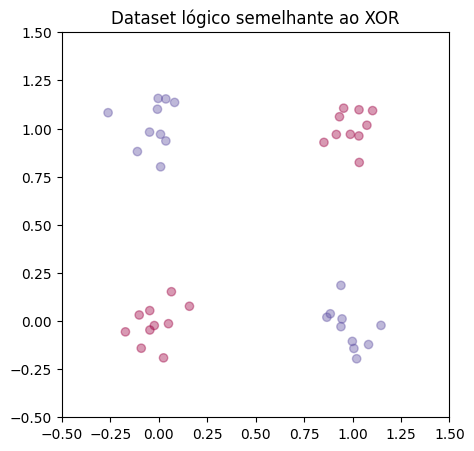

Formato de X: (40, 2)
Formato de y: (40,)
Classes: [-1  1]


In [8]:
X, y = makeLogicalDataset()
plotDataset(X, y)
plt.title("Dataset lógico semelhante ao XOR")
plt.show()

print("Formato de X:", X.shape)
print("Formato de y:", y.shape)
print("Classes:", np.unique(y))


## MLP com backpropagation

A classe abaixo mantém a estrutura da aula: entrada com bias, ativação nos neurônios ocultos, saída linear e predição pelo sinal da saída.

A diferença é que os principais parâmetros foram colocados no `__init__`: quantidade de camadas ocultas, quantidade de neurônios, função de ativação, taxa de aprendizado e número de iterações.

No notebook da aula, o backpropagation é escrito diretamente para uma única camada oculta. Nesta implementação, o mesmo cálculo foi colocado em um laço para permitir mais de uma camada oculta, conforme solicitado no enunciado. A lógica é a mesma: calcula-se o erro na saída, propaga-se esse erro para trás usando os pesos da camada seguinte e multiplica-se pela derivada da função de ativação.



In [9]:
def tanh(z):
    return np.tanh(z)


def tanh_grad(a):
    return 1 - a**2


def sigmoid(z):
    return 1 / (1 + np.exp(-z))


def sigmoid_grad(a):
    return a * (1 - a)


def relu(z):
    return np.maximum(0, z)


def relu_grad(a):
    return (a > 0).astype(float)


ACTIVATIONS = {
    "tanh": (tanh, tanh_grad),
    "sigmoid": (sigmoid, sigmoid_grad),
    "relu": (relu, relu_grad),
}


class MLP(BaseEstimator, ClassifierMixin):
    def __init__(self, hidden_layer_sizes=(2,), activations="tanh",
                 max_iter=10000, learning_rate=0.01, random_state=42):
        self.hidden_layer_sizes = hidden_layer_sizes
        self.activations = activations
        self.max_iter = max_iter
        self.learning_rate = learning_rate
        self.random_state = random_state

    def _prepare_activations(self):
        if isinstance(self.activations, str):
            names = [self.activations] * len(self.hidden_layer_sizes)
        else:
            names = list(self.activations)

        if len(names) != len(self.hidden_layer_sizes):
            raise ValueError("Informe uma função de ativação para cada camada oculta.")

        self.activation_names_ = names
        self.activation_funcs_ = [ACTIVATIONS[name][0] for name in names]
        self.activation_grads_ = [ACTIVATIONS[name][1] for name in names]

    def forward(self, X):
        # Guarda ativações para serem usadas depois no backward.
        A = X
        self.As_ = [A]
        self.Abs_ = []

        for W, activation in zip(self.weights_[:-1], self.activation_funcs_):
            Ab = include_bias(A)
            self.Abs_.append(Ab)
            A = activation(Ab @ W)
            self.As_.append(A)

        Ab = include_bias(A)
        self.Abs_.append(Ab)
        logits = Ab @ self.weights_[-1]
        return logits

    def backward(self, y, logits):
        # Erro da saída. A saída é linear e a perda usada é o erro quadrático médio.
        delta = logits - y
        n = y.shape[0]

        grads = [None] * len(self.weights_)
        grads[-1] = self.Abs_[-1].T @ delta / n

        # Propaga o erro de trás para frente.
        for i in reversed(range(len(self.hidden_layer_sizes))):
            W_next = self.weights_[i + 1][1:, :]  # ignora o peso do bias
            delta = (delta @ W_next.T) * self.activation_grads_[i](self.As_[i + 1])
            grads[i] = self.Abs_[i].T @ delta / n

        # Atualização dos pesos por descida do gradiente.
        for i in range(len(self.weights_)):
            self.weights_[i] -= self.learning_rate * grads[i]

    def fit(self, X, y):
        self.hidden_layer_sizes = tuple(self.hidden_layer_sizes)
        self._prepare_activations()

        if len(y.shape) == 1:
            y = y.reshape(-1, 1)

        rng = np.random.default_rng(self.random_state)
        layer_sizes = [X.shape[1]] + list(self.hidden_layer_sizes) + [y.shape[1]]

        self.weights_ = []
        for i in range(len(layer_sizes) - 1):
            # +1 por causa do bias.
            W = rng.uniform(-1, 1, size=(layer_sizes[i] + 1, layer_sizes[i + 1]))
            self.weights_.append(W)

        self.loss_history_ = []
        for _ in range(self.max_iter):
            logits = self.forward(X)
            self.loss_history_.append(np.mean((logits - y) ** 2))
            self.backward(y, logits)

        return self

    def predict(self, X):
        logits = self.forward(X)
        return sign(logits).ravel()


Accuracy do MLP implementado: 1.0000


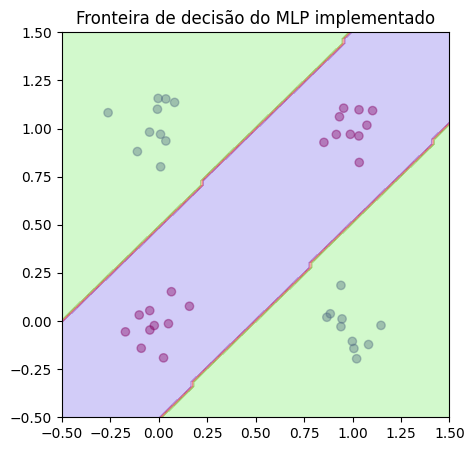

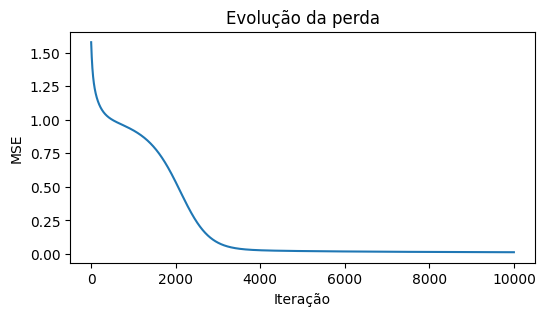

In [10]:
model = MLP(
    hidden_layer_sizes=(2,),
    activations="tanh",
    max_iter=10000,
    learning_rate=0.01,
    random_state=42,
)

model.fit(X, y)
ypred = model.predict(X)

print(f"Accuracy do MLP implementado: {accuracy_score(y, ypred):.4f}")

plotDataset(X, y)
plotPredictions(model, X)
plt.title("Fronteira de decisão do MLP implementado")
plt.show()

plt.figure(figsize=(6, 3))
plt.plot(model.loss_history_)
plt.title("Evolução da perda")
plt.xlabel("Iteração")
plt.ylabel("MSE")
plt.show()


## Comparação com Scikit-Learn

A comparação abaixo usa o `MLPClassifier` com a mesma ideia geral: uma camada oculta com dois neurônios e ativação `tanh`.

Accuracy do MLP implementado: 1.0000
Accuracy do Scikit-Learn:      1.0000


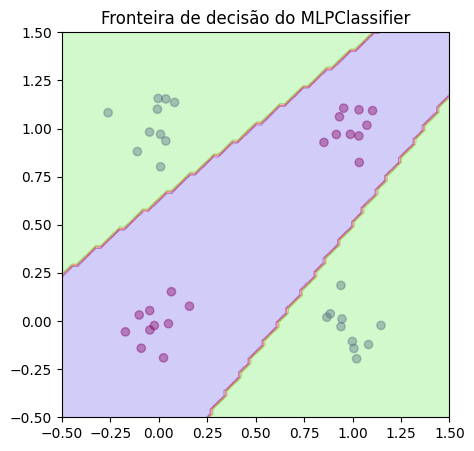

In [11]:
sk_model = MLPClassifier(
    hidden_layer_sizes=(2,),
    activation="tanh",
    solver="lbfgs",  # bom para bases pequenas; a comparação aqui é com a biblioteca, não com o mesmo otimizador
    max_iter=10000,
    random_state=42,
)

sk_model.fit(X, y)
sk_pred = sk_model.predict(X)

print(f"Accuracy do MLP implementado: {accuracy_score(y, ypred):.4f}")
print(f"Accuracy do Scikit-Learn:      {accuracy_score(y, sk_pred):.4f}")

plotDataset(X, y)
plotPredictions(sk_model, X)
plt.title("Fronteira de decisão do MLPClassifier")
plt.show()


## Pequeno teste dos parâmetros

A célula abaixo não é um novo experimento completo. Ela apenas mostra que a classe permite mudar a arquitetura e a função de ativação.


In [12]:
configs = [
    {"hidden_layer_sizes": (2,), "activations": "tanh"},
    {"hidden_layer_sizes": (4,), "activations": "tanh"},
    {"hidden_layer_sizes": (4, 3), "activations": ("tanh", "tanh")},
    {"hidden_layer_sizes": (4, 3), "activations": ("relu", "tanh")},
]

for cfg in configs:
    m = MLP(**cfg, max_iter=10000, learning_rate=0.01, random_state=42)
    m.fit(X, y)
    acc = accuracy_score(y, m.predict(X))
    print(f"camadas={cfg['hidden_layer_sizes']}, ativações={cfg['activations']}, accuracy={acc:.4f}")


camadas=(2,), ativações=tanh, accuracy=1.0000
camadas=(4,), ativações=tanh, accuracy=1.0000
camadas=(4, 3), ativações=('tanh', 'tanh'), accuracy=1.0000
camadas=(4, 3), ativações=('relu', 'tanh'), accuracy=1.0000


## Conclusão

O notebook implementou um MLP simples com backpropagation usando NumPy. O modelo foi testado no problema lógico do tipo XOR e comparado com o `MLPClassifier` do Scikit-Learn.

A implementação manteve a ideia da aula, mas deixou alguns parâmetros configuráveis, como quantidade de camadas ocultas, neurônios por camada e função de ativação.
